In [1]:
from GeoEntityModel import GeoEntityModel
import torch, math
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from GeoUtils import collator, GeoDataset
from torch.utils.data import DataLoader
from globals import ID2LABEL_GEONER, LABEL2ID_GEONER

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [2]:
cleandata_path = "D:\\GeoTKG\\cleandata\\geo\\"
train = GeoDataset(cleandata_path + "train.json")
eval = GeoDataset(cleandata_path + "eval.json")
train_loader = DataLoader(train, batch_size=8, shuffle=True, collate_fn=collator)
eval_loader = DataLoader(eval, batch_size=8, shuffle=False, collate_fn=collator)

In [3]:
NUM_EPOCHS = 50
ENC_LR = 5e-5
NONENC_LR = 1e-3
WARMUP_EPOCHS = 5
LOGGING_STEPS = 400
EVALUATION_EPOCHS = 10
BASE_ENC_MODEL = "roberta-base"
GRAD_ACCUM = 4
WEIGHT_DECAY = 0.01

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = GeoEntityModel(base=BASE_ENC_MODEL).to(device)
for p in model.enc.parameters(): p.requires_grad = False

optimizer = AdamW([
        {"params": [p for n,p in model.named_parameters() if n.startswith("enc.")], "lr": ENC_LR},
        {"params": [p for n,p in model.named_parameters() if not n.startswith("enc.")], "lr": NONENC_LR},
    ], weight_decay=0.01)

steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM)
num_train_steps = steps_per_epoch * NUM_EPOCHS
num_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_train_steps)

scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

def make_optim(unfrozen: bool):
    groups = []
    if unfrozen:
        groups.append({"params": model.enc.parameters(), "lr": ENC_LR})
    else:
        # keep enc group empty or skip entirely; either is fine
        pass
    nonenc = [p for n, p in model.named_parameters() if not n.startswith("enc.")]
    groups.append({"params": nonenc, "lr": NONENC_LR})
    return AdamW(groups, weight_decay=WEIGHT_DECAY)

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.weight', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.bias', 'lm_head.dense.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initializ

In [6]:
global_step = 0
history = {"loss": [], "f1": [], "eval_loss":[], "lr": [], "step": []}
for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

        ctx = (torch.autocast(device_type='cuda', dtype=torch.float16))
        with ctx:
            # Ensure your model.forward signature matches these keys
            out = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["ner_labels"],
            )
            loss = out["loss"] / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            prev_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            sched.step() if scaler.get_scale() <= prev_scale else None
            optimizer.zero_grad(set_to_none=True)
            global_step += 1
            
            if global_step % LOGGING_STEPS == 0:
                print(f"LOSS: {loss.item():.4f}, STEP: {global_step}, EPOCH: {global_step / steps_per_epoch:.2f}, LR: {optimizer.param_groups[0]['lr']:.8f}")
                history["loss"].append(loss.item())
                history['step'].append(global_step)
                history['lr'].append(optimizer.param_groups[0]['lr'])
        
    # ---- unfreeze after warmup epochs ----
    if epoch + 1 == WARMUP_EPOCHS:
        for p in model.enc.parameters():
            p.requires_grad = True
        # rebuild optimizer & scheduler for the remaining steps
        optimizer = make_optim(unfrozen=True)
        remaining_steps = steps_per_epoch * (NUM_EPOCHS - (epoch + 1))
        warmup_rem = 0  # already warmed up; or set a small extra warmup if you like
        sched = get_cosine_schedule_with_warmup(optimizer, warmup_rem, remaining_steps)

    # ---- validation ----
    if (epoch + 1) % EVALUATION_EPOCHS == 0:
        model.eval()
        with torch.no_grad():
            batch_evaluation = model.evaluate_dataloader(eval_loader)
            history["f1"].append(batch_evaluation["f1"])
            history["eval_loss"].append(batch_evaluation["eval_loss"])
        print(f"EPOCH{epoch+1}: F1={batch_evaluation['f1']:.4f}, EVAL_LOSS={batch_evaluation['eval_loss']:.4f}")

d:\GeoTKG\venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


LOSS: 0.2828, STEP: 400, EPOCH: 0.40, LR: 0.00000400
LOSS: 0.1023, STEP: 800, EPOCH: 0.80, LR: 0.00000801
LOSS: 0.0631, STEP: 1200, EPOCH: 1.20, LR: 0.00001201
LOSS: 0.0702, STEP: 1600, EPOCH: 1.60, LR: 0.00001602
LOSS: 0.0592, STEP: 2000, EPOCH: 2.00, LR: 0.00002002
LOSS: 0.0419, STEP: 2400, EPOCH: 2.40, LR: 0.00002401
LOSS: 0.0375, STEP: 2800, EPOCH: 2.80, LR: 0.00002802
LOSS: 0.0710, STEP: 3200, EPOCH: 3.20, LR: 0.00003202
LOSS: 0.0612, STEP: 3600, EPOCH: 3.60, LR: 0.00003603
LOSS: 0.0454, STEP: 4000, EPOCH: 4.00, LR: 0.00004003
LOSS: 0.0333, STEP: 4400, EPOCH: 4.40, LR: 0.00004402
LOSS: 0.0689, STEP: 4800, EPOCH: 4.80, LR: 0.00004803
LOSS: 0.0267, STEP: 5200, EPOCH: 5.21, LR: 0.00005000
LOSS: 0.0191, STEP: 5600, EPOCH: 5.61, LR: 0.00004998
LOSS: 0.0013, STEP: 6000, EPOCH: 6.01, LR: 0.00004994
LOSS: 0.0091, STEP: 6400, EPOCH: 6.41, LR: 0.00004988
LOSS: 0.0007, STEP: 6800, EPOCH: 6.81, LR: 0.00004980
LOSS: 0.0211, STEP: 7200, EPOCH: 7.21, LR: 0.00004970
LOSS: 0.0016, STEP: 7600, EPOC

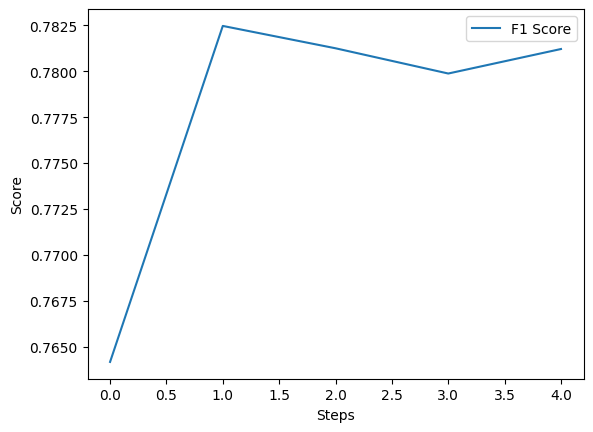

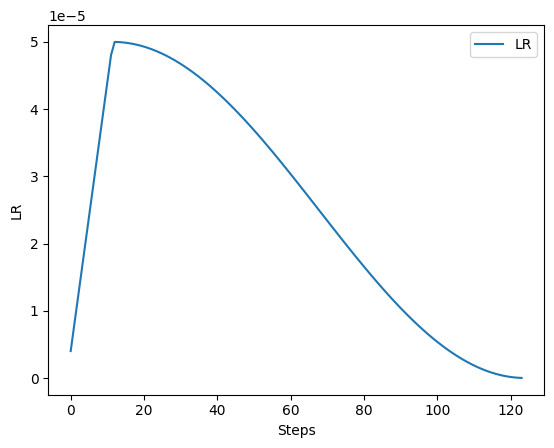

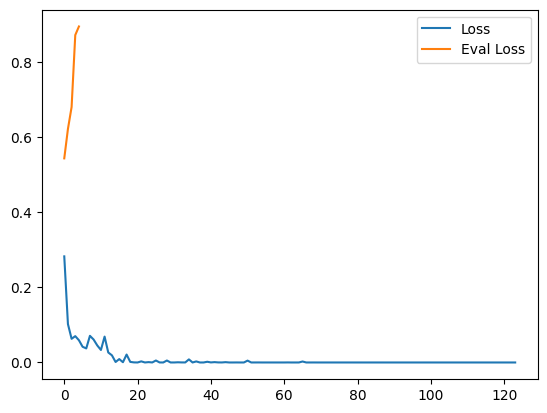

In [7]:
import matplotlib.pyplot as plt

plt.plot(history["f1"], label="F1 Score")
plt.xlabel("Steps")
plt.ylabel("Score")
plt.legend()
plt.show()

plt.plot(history["lr"], label="LR")
plt.xlabel("Steps")
plt.ylabel("LR")
plt.legend()
plt.show()

plt.plot(history["loss"], label="Loss")
plt.plot(history["eval_loss"], label="Eval Loss")
plt.legend()
plt.show()

In [8]:
model.save("results/geo_model/")

In [11]:
import json
with open("results/geo_model/history.json", "w") as f:
    json.dump(history, f, indent=2)